# Mean field

In [1]:
using Plots
using ProgressMeter

In [2]:
function describe_mean_field(J1,J2,J3)
    I1 = -2*(J1+J2+4*J3)
    I2 = -1/8*(J1+4*J2+16*J3)
    I3 = 1/24*(J1-4*J2+16*J3)
    println("I1 = ", I1,"\nI2 = ", I2)
    println("spatial anisotropy ratio : ", I3/I2)
    x0 = sqrt(I2/I1)
    println("sqrt(I2/I1) length scale = ", x0)
    println("H_MF = ",I2/I1^2, " H_Micro")
    return x0
end
J1 = 1.0; J2 = -0.5; J3 = 1/16*(-J1+4*J2); K = 0.0
describe_mean_field(J1,J2,J3)

I1 = 0.5
I2 = 0.5
spatial anisotropy ratio : 0.0
sqrt(I2/I1) length scale = 1.0
H_MF = 2.0 H_Micro


1.0

## The Hamiltonian and low-energy configurations

### Configuration energy

In [48]:
function H_vect(n, J1, J2, J3, K, B, boundary)
    """
    Computes the energy of a classical magnetization field
    """
    E = 0.0
    nx, ny = size(n, 2), size(n, 3)
    for i in 1:nx
        for j in 1:ny
            n_a = n[:, i, j]
            # account for the anisotropy
            E -= K * n_a[3]^2
            # add external field
            E -= B[i, j] * n_a[3]
            for (k, l) in [(i+1, j), (i, j+1)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                n_b = n[:, k, l]
                E -= J1 * (n_a[1]*n_b[1] + n_a[2]*n_b[2] + n_a[3]*n_b[3])
            end
            for (k, l) in [(i+1, j+1), (i+1, j-1)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                n_b = n[:, k, l]
                E -= J2 * (n_a[1]*n_b[1] + n_a[2]*n_b[2] + n_a[3]*n_b[3])
            end
            for (k, l) in [(i+2, j), (i, j+2)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                n_b = n[:, k, l]
                E -= J3 * (n_a[1]*n_b[1] + n_a[2]*n_b[2] + n_a[3]*n_b[3])
            end
        end
    end

    # subtract the energy of the FM state
    if boundary == "periodic"
        E += sum(B[1:1:nx,1:1:ny]) + nx * ny * (K + 2*J1 + 2*J2 + 2*J3)
    elseif boundary == "free"
        E += sum(B[1:1:nx,1:1:ny]) + nx * ny * K + J1 * (2*nx*ny - (nx + ny)) + J2 * (2*nx*ny - 2*(nx + ny) + 2) + J3 * (2*nx*ny - 2*(nx + ny))
    end
    return E
end

H_vect (generic function with 1 method)

In [69]:
function ferromagnetic(nx,ny)
    n = zeros(3,nx,ny)
    n[3,:,:] .= 1.0
    return n
end

function normalize!(n)
    for i=1:n.size[2]
        for j=1:n.size[3]
            n[:,i,j] *= 1/sqrt(sum(n[:,i,j].^2))
        end
    end
    return n
end

function check_norm(n)
    norm = zeros(n.size[2],n.size[3])
    for i=1:n.size[2]
        for j=1:n.size[3]
            norm[i,j] = sqrt(sum(n[:,i,j].^2))
        end
    end
    println("Norm varies from ", min.(norm), "to", max.(norm))
end

function random_configuration(nx,ny)
    n = randn((3,nx,ny))
    normalize!(n)
    return n
end

function rotate_around_z(n, phi)
    n_new = copy(n)
    n_new[1,:,:] = cos(phi) * n[1,:,:] - sin(phi) * n[2,:,:]
    n_new[2,:,:] = sin(phi) * n[1,:,:] + cos(phi) * n[2,:,:]
    return n_new
end

function uniform_B(nx,ny,B_val)
    return B_val*ones(nx,ny)
end

let
    nx = 10; ny = 7
    J1 = 1.12; J2 = -122.521; J3 = 1/16*(-J1+4*J2)+0.23; K = 0.007
    B = uniform_B(nx,ny,-0.123)
    boundary = "periodic"
    E_FM = H_vect(ferromagnetic(nx,ny), J1, J2, J3, K, B, boundary)
    if abs(E_FM) < 1e-10
        println("correct FM energy ------> OK")
    end
end

correct FM energy ------> OK


In [70]:
let
    nx = 5; ny = 6
    J1 = 1.12; J2 = -0.521; J3 = 1/16*(-J1+4*J2)+0.23; K = 0.007
    B = uniform_B(nx,ny,0.12)
    boundary = "free"
    err = 0.0
    for case=1:30
        n = random_configuration(nx,ny)
        H = H_vect(n, J1, J2, J3, K, B, boundary)
        n_new = rotate_around_z(n,2pi*rand())
        H_new = H_vect(n_new, J1, J2, J3, K, B, boundary)
        diff = abs(H-H_new)
        if (diff>err) err = diff end
    end
    println("err = ", err)
    if err<1e-10
        println("S_z invariance ------> test passed")
    end
end

err = 7.105427357601002e-15
S_z invariance ------> test passed


### Relaxation dynamics

To minimize the energy, we would like to perform gradient descent on $n$ :
$$
\dot{n} = - \nabla_n H
$$
But this would be unphysical as we need to ensure $|n|=1$. To fix the issue, we simply subtract from the RHS the part proportional to $n$, obtaining
$$
\dot{n} = -\nabla_n H + (n \cdot \nabla_n H) \; n
$$
so that $n \dot{n} = 0$.

Maybe a ($n^2=1$ constrained) variant of Newton's method could be used? The Hessian is easy enough to compute, since $H$ is quadratic in $n$.

Progress: 100%|█████████████████████████████████████████| Time: 0:00:06


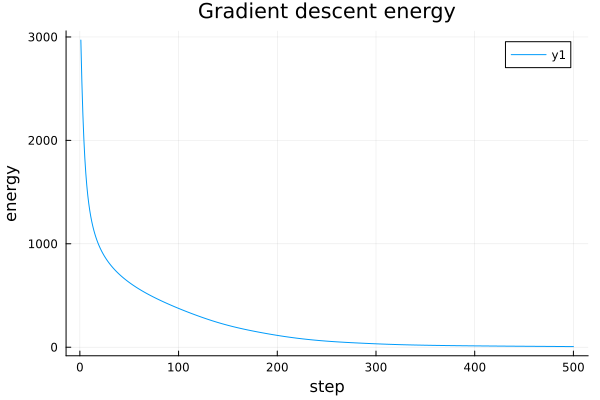

3×50×50 Array{Float64, 3}:
[:, :, 1] =
 -0.0630159  -0.0657194  -0.0684122  …   0.0793255   0.076779    0.0745419
  0.0299678   0.0290929   0.0270212     -0.0223815  -0.0306886  -0.0355658
  0.997563    0.997414    0.997292       0.996598    0.996576    0.996584

[:, :, 2] =
 -0.0596948  -0.0620857  -0.0646804  …   0.0764527   0.0740376   0.0721187
  0.0283304   0.026274    0.0226652     -0.0284596  -0.0363213  -0.0396697
  0.997815    0.997725    0.997649       0.996668    0.996594    0.996607

[:, :, 3] =
 -0.0556386  -0.0570938  -0.0588547  …   0.0730125   0.0712081   0.0697695
  0.0264852   0.023776    0.0195198     -0.0313042  -0.0386709  -0.0413322
  0.9981      0.998086    0.998076       0.99684     0.996712    0.996707

;;; … 

[:, :, 48] =
 -0.0610587  -0.0587829   …  -0.0042468  -0.00705547  -0.0108269
 -0.0108355  -0.00759548     -0.0249232  -0.0238706   -0.023127
  0.998076    0.998242        0.99968     0.99969      0.999674

[:, :, 49] =
 -0.0626441   -0.0603803   -0.0567

In [6]:
function descent_gradient!(g::Array{Float64,3}, n::Array{Float64,3}, nx::Int, ny::Int, J1::Float64, J2::Float64, 
    J3::Float64, K::Float64, B::Array{Float64,2}, boundary::String)
    g .= 0.0 # the gradient
    for i in 1:nx
        for j in 1:ny
            # external field
            g[3,i,j] += B[i,j]
            # anisotropy
            g[:,i,j] .+= 2*K*n[:,i,j]

            for (k,l) in [(i+1,j),(i,j+1)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                g[:,i,j] .+= J1 * n[:,k,l]
                g[:,k,l] .+= J1 * n[:,i,j]
            end

            for (k,l) in [(i+1,j+1),(i+1,j-1)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                g[:,i,j] .+= J2 * n[:,k,l]
                g[:,k,l] .+= J2 * n[:,i,j]
            end

            for (k,l) in [(i+2,j),(i,j+2)]
                if boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                else # free BCs
                    if k > nx || l > ny || k < 1 || l < 1
                        continue
                    end
                end
                g[:,i,j] .+= J3 * n[:,k,l]
                g[:,k,l] .+= J3 * n[:,i,j]
            end
        end
    end

    for i in 1:nx
        for j in 1:ny
            gn = n[1,i,j]*g[1,i,j] + n[2,i,j]*g[2,i,j] + n[3,i,j]*g[3,i,j]
            g[:,i,j] .-= gn * n[:,i,j]
        end
    end
end

function relax(n_init::Array{Float64,3}, nx::Int, ny::Int, J1::Float64, J2::Float64, 
    J3::Float64, K::Float64, B::Array{Float64,2}, dt::Float64, N_steps::Int, boundary::String)
    """
    Gradient descent on H
    """
    g = zeros(size(n_init))
    n = copy(n_init)
    k1 = similar(n_init)

    H_vals = zeros(N_steps)

    @showprogress for i in 1:N_steps
        descent_gradient!(k1,n, nx, ny, J1, J2, J3, K, B, boundary)
        
        # Euler's method
        n .+= k1 .* dt

        # save the energy value
        H_vals[i] = H_vect(n, J1, J2, J3, K, B, boundary)
    end

    P = plot(H_vals)
    xlabel!(P,"step")
    ylabel!(P,"energy")
    title!(P, "Gradient descent energy")
    display(P)
    
    return n
end

nx = 50; ny = 50
J1 = 1.12; J2 = -0.521; J3 = 1/16*(-J1+4*J2)+0.23; K = 0.007
B = uniform_B(nx,ny,0.12)
boundary = "free"
n_init = random_configuration(nx,ny)

dt = 0.05;
N_steps = 500
boundary = "free"
n_final = relax(n_init,nx,ny,J1,J2,J3,K,B,dt,N_steps,boundary)

## Skyrmions

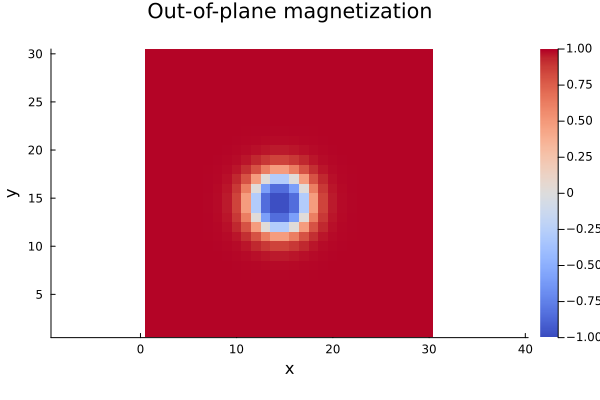

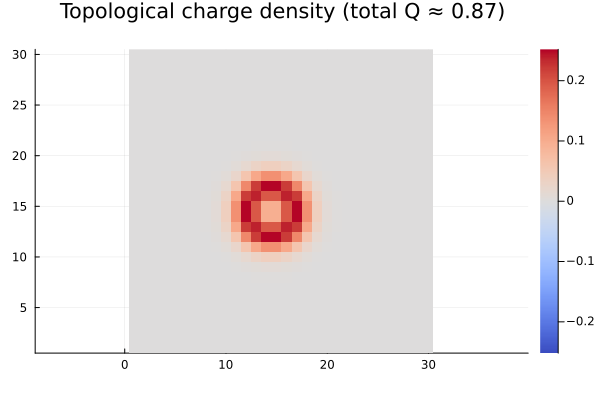

In [67]:
function skyrmion_ansatz(nx, ny, R_0)
    """
    generates a config with Q=1 via a stereographic projection of id: S^2 -> S^2;
    b is the size of the 'skyrmion'
    """
    X = repeat(collect(1.0:nx)', ny, 1)
    Y = repeat(collect(1.0:ny), 1, nx)

    # shift the centre
    X .-= (nx - 1) ÷ 2 + 0.5
    Y .-= (ny - 1) ÷ 2 + 0.5

    R = sqrt.(X.^2 .+ Y.^2)
    l0 = 2.0
    theta = π .- 2 .* atan.(R .* exp.((R .- R_0) ./ l0))

    # compute the projection
    n = zeros(Float64, 3, nx, ny)
    n[1, :, :] .= sin.(theta) .* X ./ R
    n[2, :, :] .= sin.(theta) .* Y ./ R
    n[3, :, :] .= cos.(theta)
    return n
end

function gradient(f, dx, dy)
    nx, ny = size(f)
    dfdx = zeros(Float64, nx, ny)
    dfdy = zeros(Float64, nx, ny)

    # central differences for interior points
    for i in 2:nx-1, j in 1:ny
        dfdx[i, j] = (f[i+1, j] - f[i-1, j]) / (2dx)
    end
    # forward/backward differences for boundaries
    for j in 1:ny
        dfdx[1, j] = (f[2, j] - f[1, j]) / dx
        dfdx[nx, j] = (f[nx, j] - f[nx-1, j]) / dx
    end

    for i in 1:nx, j in 2:ny-1
        dfdy[i, j] = (f[i, j+1] - f[i, j-1]) / (2dy)
    end
    for i in 1:nx
        dfdy[i, 1] = (f[i, 2] - f[i, 1]) / dy
        dfdy[i, ny] = (f[i, ny] - f[i, ny-1]) / dy
    end

    return dfdx, dfdy
end

function topological_charge(n)
    m_x, m_y, m_z = n[1, :, :], n[2, :, :], n[3, :, :]

    dx = 1.0
    dy = 1.0
    dmx_dx, dmx_dy = gradient(m_x, dx, dy)
    dmy_dx, dmy_dy = gradient(m_y, dx, dy)
    dmz_dx, dmz_dy = gradient(m_z, dx, dy)

    cross_x = dmy_dx .* dmz_dy .- dmz_dx .* dmy_dy
    cross_y = dmz_dx .* dmx_dy .- dmx_dx .* dmz_dy
    cross_z = dmx_dx .* dmy_dy .- dmy_dx .* dmx_dy

    density = m_x .* cross_x .+ m_y .* cross_y .+ m_z .* cross_z
    Q = (1 / (4 * π)) * sum(density) * dx * dy

    return Q, density
end

function show_skyrmion(n)
    x0 = 1
    x1 = size(n, 2)

    # spin z
    Heatmap = heatmap(n[3, :, :]', clims=(-1, 1), color=:coolwarm, xlabel="x", ylabel="y",
            title="Out-of-plane magnetization", aspect_ratio=:1, grid=false)
    display(Heatmap)

    # in-plane
    #quiver(n[1, :, :]', n[2, :, :]', xlabel="x", ylabel="y", aspect_ratio=:equal)

    Q, density = topological_charge(n)
    max_d = maximum(abs.(density))
    heatmap(density', clims=(-max_d, max_d), color=:coolwarm, aspect_ratio=:1,
            title="Topological charge density (total Q ≈ $(round(Q, digits=2)))")
end

nx = 30; ny = 30; R_0 = 5.0
n = skyrmion_ansatz(nx,ny,R_0)
show_skyrmion(n)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


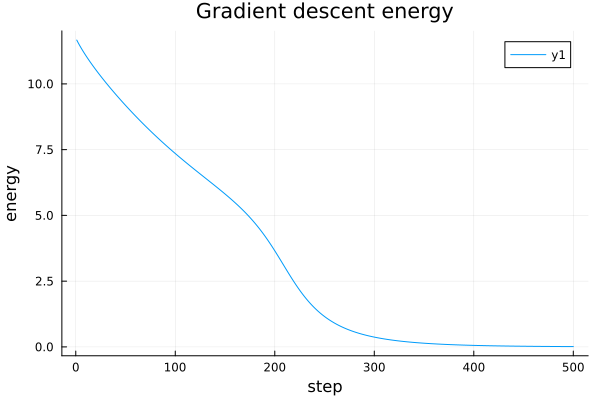

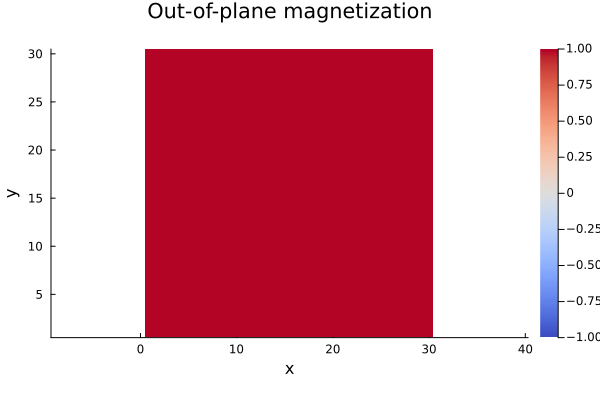

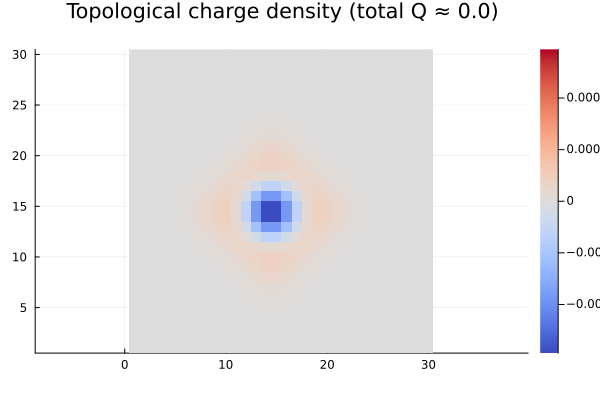

In [68]:
n_relaxed = relax(n,nx,ny,J1,J2,J3,K,B,dt,N_steps,boundary)
show_skyrmion(n_relaxed)

## Stereographic projection

In [73]:
function w_project(n::Array{Float64,3})
    nx, ny = size(n, 2), size(n, 3)
    w = (n[1, :, :] .+ im * n[2, :, :]) ./ (1 .+ n[3, :, :])
    return w
end

function n_vector(w::Array{ComplexF64,2})
    nx, ny = size(w)
    n = zeros(Float64, 3, nx, ny)
    denom = 1 .+ conj.(w) .* w
    n[1, :, :] .= real.((w .+ conj.(w)) ./ denom)
    n[2, :, :] .= real.(-im .* (w .- conj.(w)) ./ denom)
    n[3, :, :] .= real.((1 .- w .* conj.(w)) ./ denom)
    return n
end

function H(w::Array{ComplexF64,2}, z::Array{ComplexF64,2}, nx::Int, ny::Int, J1::Float64, J2::Float64, J3::Float64, K::Float64, B::Array{Float64,2}, boundary::String)
    E = 0.0
    for i in 1:nx
        for j in 1:ny
            w1 = w[i, j]
            z1 = z[i, j]
            for (k, l, J) in [(i+1, j, J1), (i, j+1, J1), (i+1, j+1, J2), (i+1, j-1, J2), (i+2, j, J3), (i, j+2, J3)]
                if boundary == "free"
                    if k < 1 || l < 1 || k > nx || l > ny
                        continue
                    end
                elseif boundary == "periodic"
                    k = mod1(k, nx)
                    l = mod1(l, ny)
                end

                w2 = w[k, l]
                z2 = z[k, l]

                E += -J * (2 * (w1 * z2 + z1 * w2) + (1 - z1 * w1) * (1 - z2 * w2)) / ((1 + w1 * z1) * (1 + w2 * z2))
            end
            n_z = (1 - w1 * z1) / (1 + w1 * z1)
            E += -B[i, j] * n_z - K * n_z^2
        end
    end

    if boundary == "free"
        E += J1 * (2 * nx * ny - (nx + ny)) + J2 * (2 * nx * ny - 2 * (nx + ny) + 1) + J3 * (2 * nx * ny - 2 * (nx + ny)) + sum(B) + K * nx * ny
    elseif boundary == "periodic"
        E += nx * ny * (2 * J1 + 2 * J2 + 2 * J3 + K) + sum(B)
    end
    return E
end

H (generic function with 1 method)

In [80]:
function dHdl(w0,w,z,nx,ny,J1,J2,J3,K,B,boundary)
    dH = 0.0
    #sum over all bonds
    dw = (w0-np.conj(w0))/2
    for i=1:nx
        for j=1:ny
            w1 = w[i,j]; z1 = z[i,j]; dw1 = dw[i,j]
            for (k,l,J) in [(i+1,j,J1), (i,j+1,J1), (i+1,j+1,J2), (i+1,j-1,J2), (i+2,j,J3), (i,j+2,J3)]
                if boundary == "free"
                    if k < 1 || l < 1 || k > nx || l > ny
                        continue
                    end
                elseif boundary == "periodic"
                    k = k%nx; l = l%ny
                end
                
                w2 = w[k,l]; z2 = z[k,l]; dw2 = dw[k,l]
                
                dH += -2*J / ((1+w1*z1)*(1+w2*z2)) * ( dw1*(z2-z1*z1*w2-z1*(1-w2*z2))/(1+w1*z1) + dw2*(z1-z2*z2*w1-z2*(1-w1*z1))/(1+w2*z2) )
            end 
            n_z = (1-w1*z1)/(1+w1*z1);
            dn_z = -2*z1/(1+w1*z1)
            dH += -B[i,j]*dn_z - K*2*n_z*dn_z
        end
    end
    return dH
end

function M(w0,w,z)
    return sum( imag(w0).^2 / (1+w*z ).^2 )
end

function v(w0,lambda_,lambda_bar, nx, ny, J1, J2, J3, K, B, boundary)
    #compute the field
    w = real(w0) + 1j*imag(w0)*lambda_
    z = real(w0) - 1j*imag(w0)*lambda_bar
    M_val = M(w0,w,z)
    dHdlambda = dHdl(w0,w,z,nx,ny,J1,J2,J3,K,B,boundary)
    dHdlambda_bar = -dHdl(w0,z,w,nx,ny,J1,J2,J3,K,B,boundary) #notice the minus sign and the exchange w <> z. It is justified by a symmetry argument
    return -dHdlambda_bar/M_val, dHdlambda/M_val
end

v(w0,4.0,-1.0,nx,ny,J1,J2,J3,K,B,boundary)

UndefVarError: UndefVarError: `w0` not defined in `Main`
Suggestion: check for spelling errors or missing imports.